## Looping Graph


In [23]:
from typing import TypedDict


# --- 1. STATE ---
class State(TypedDict):
    target: int  # we want to generate this number
    attempts: int  # how many times we have tried
    guess: int  # the latest guess
    passed: bool  # did the guess match the target?

In [24]:
from typing import Literal
import random
from langgraph.graph import END


# --- 2. NODES ---
def guess_node(state: State) -> dict:
    """Simulate generating an answer (random guess 1–5)"""
    attempts = state["attempts"] + 1
    guess = random.randint(1, 5)
    passed = guess == state["target"]
    print(
        f"[guess]  Attempt #{attempts}: guessed {guess} | target {state['target']} | {'✅ PASS' if passed else '❌ FAIL'}"
    )
    return {"attempts": attempts, "guess": guess, "passed": passed}


# ─────────────────────────────────────────────────────
# 🔷 LOOP — The routing function returns "guess" (a node
# that already ran), which causes the graph to loop back.
# This is how cycles are created in LangGraph.
# ─────────────────────────────────────────────────────
def should_continue(state: State) -> Literal["guess", "__end__"]:
    if state["passed"]:
        print(f"✅ Correct! Found target in {state['attempts']} attempt(s).")
        return END
    if state["attempts"] >= 5:
        print(f"⚠️  Max attempts reached. Stopping.")
        return END
    print(f"🔄 Looping back to try again...")
    return "guess"  # ← sends execution BACK to guess_node

In [25]:
from langgraph.graph import StateGraph, START, END

# --- 3. GRAPH CONSTRUCTION ---
builder = StateGraph(State)

builder.add_node("guess", guess_node)

builder.add_edge(START, "guess")
builder.add_conditional_edges(
    "guess",
    should_continue,
    {
        "guess": "guess",
        END: END,
    },
)  # loop back OR stop

graph = builder.compile()

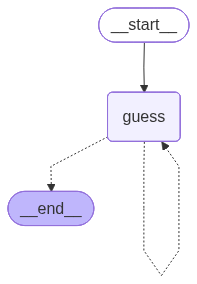

In [26]:
# --- 4. VISUALIZE ---
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
import random

# --- 5. RUN & TEST ---
random.seed(2)
result = graph.invoke(
    {
        "target": 3,
        "attempts": 0,
        "guess": 0,
        "passed": False,
    }
)
print(f"\nFinal state: guess={result['guess']}, attempts={result['attempts']}, passed={result['passed']}")

[guess]  Attempt #1: guessed 1 | target 3 | ❌ FAIL
🔄 Looping back to try again...
[guess]  Attempt #2: guessed 2 | target 3 | ❌ FAIL
🔄 Looping back to try again...
[guess]  Attempt #3: guessed 3 | target 3 | ✅ PASS
✅ Correct! Found target in 3 attempt(s).

Final state: guess=3, attempts=3, passed=True
